In [49]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to C:\Users\Nossim
[nltk_data]     Sankaire\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [50]:
try:
    data_path = "../data/train_raw.csv"
    df = pd.read_csv(data_path, encoding='utf-8', on_bad_lines='warn') 
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print(f" Error: File not found at {data_path}. Check the path.")
except Exception as e:
    print(f" An error occurred: {e}")

Dataset loaded successfully. Shape: (400, 12)


In [51]:
df.shape
df.dtypes
df.isnull().sum().sort_values(ascending=False).head(10)
if 'Clinician' in df.columns:
    df['Clinician'].head(3)
else:
    print("'Clinician' column not found in dataset")


In [52]:
def clean_text_advanced(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = re.sub(r'_x000D_|_x0001_|\\n|\\t', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()   
    return text


In [53]:
# Cleaning of textual columns
text_columns = ['Prompt', 'Clinician', 'GPT4.0', 'LLAMA', 'GEMINI', 'DDX SNOMED', 'Nursing Competency', 'Clinical Panel', 'County']
for col in text_columns:
    if col in df.columns:
        df[f"{col}_clean"] = df[col].apply(clean_text_advanced)
    else:
        print(f"Warning: Column '{col}' not found in dataframe.")

# Handle missing values in 'Years of Experience' - fill with median or mean, flag
if 'Years of Experience' in df.columns:
    exp_median = df['Years of Experience'].median()
    df['Years of Experience'].fillna(exp_median, inplace=True)
    print(f"Filled missing 'Years of Experience' with median value: {exp_median}")

print(f"Filled missing 'Years of Experience' with median value: {exp_median}.")


Filled missing 'Years of Experience' with median value: 15.0
Filled missing 'Years of Experience' with median value: 15.0.


C:\Users\Nossim Sankaire\AppData\Local\Temp\ipykernel_9508\731643821.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Years of Experience'].fillna(exp_median, inplace=True)


In [54]:

df.head(6)  


,Master_Index,County,Health level,Years of Experience,Prompt,Nursing Competency,Clinical Panel,Clinician,GPT4.0,LLAMA,...,DDX SNOMED,Prompt_clean,Clinician_clean,GPT4.0_clean,LLAMA_clean,GEMINI_clean,DDX SNOMED_clean,Nursing Competency_clean,Clinical Panel_clean,County_clean
0,ID_VBWWP,Uasin Gishu,Sub-county Hospitals and Nursing Homes,18.0,I am a nurse with 18 years of experience in Ge...,Pediatric Emergency Burns,SURGERY,Summary:\nA 4 year old with 5% superficial bur...,Given your vast experience as a nurse in Uasin...,1. Immediate treatment protocol for second-deg...,...,288514009 | Burn involving 5 percent of body s...,I am a nurse with 18 years of experience in Ge...,Summary: A 4 year old with 5% superficial burn...,Given your vast experience as a nurse in Uasin...,1. Immediate treatment protocol for second-deg...,Here's a response addressing the questions reg...,288514009 | Burn involving 5 percent of body s...,Pediatric Emergency Burns,SURGERY,Uasin Gishu
1,ID_XMBBY,Uasin Gishu,National Referral Hospitals,17.0,I am a nurse with 17 years of experience in Ge...,Child Health,PAEDIATRICS,Summary\n6-year-old present with vomiting and ...,Clinical Summary: • A 6-year-old girl w...,Based on the symptoms and signs you've describ...,...,420270002 | Ketoacidosis due to type 1 diabete...,I am a nurse with 17 years of experience in Ge...,Summary 6-year-old present with vomiting and a...,Clinical Summary: • A 6-year-old girl with kno...,Based on the symptoms and signs you've describ...,"Based on the presentation, the 6-year-old girl...",420270002 | Ketoacidosis due to type 1 diabete...,Child Health,PAEDIATRICS,Uasin Gishu
2,ID_JZNZW,Kiambu,Sub-county Hospitals and Nursing Homes,12.0,I am a nurse with 12 years of experience in Ge...,General Emergency,INTERNAL MEDICINE,Summary\nA 47-year-old man presents with sever...,"In this case, you're dealing with a 47-year-ol...","Firstly, I must commend you on your thorough h...",...,13200003 | Peptic ulcer (disorder)\n25458004 |...,I am a nurse with 12 years of experience in Ge...,Summary A 47-year-old man presents with severe...,"In this case, you're dealing with a 47-year-ol...","Firstly, I must commend you on your thorough h...","This 47-year-old male presenting with severe, ...",13200003 | Peptic ulcer (disorder) 25458004 | ...,General Emergency,INTERNAL MEDICINE,Kiambu
3,ID_QOQTK,Uasin Gishu,National Referral Hospitals,12.0,I am a nurse with 12 years of experience in Pr...,Critical Care,INTERNAL MEDICINE,SUMMARY\n\n72-year-old female with inability t...,"Given ER's clinical presentation and vitals, t...",to me with this query. Based on the informatio...,...,14760008 | Constipation (finding)\n419284004 |...,I am a nurse with 12 years of experience in Pr...,SUMMARY 72-year-old female with inability to w...,"Given ER's clinical presentation and vitals, t...",to me with this query. Based on the informatio...,This 92-year-old female patient (ER) presents ...,14760008 | Constipation (finding) 419284004 | ...,Critical Care,INTERNAL MEDICINE,Uasin Gishu
4,ID_ZFJBM,Uasin Gishu,National Referral Hospitals,16.0,I am a nurse with 16 years of experience in Ge...,Adult Health,INTERNAL MEDICINE,"A 22 year old female presents with headache, d...",The 22-year-old female patient is presenting w...,Thank you for presenting this case. Based on t...,...,95874006 | Carbon monoxide poisoning from fire...,I am a nurse with 16 years of experience in Ge...,"A 22 year old female presents with headache, d...",The 22-year-old female patient is presenting w...,Thank you for presenting this case. Based on t...,This 22-year-old female patient presents with ...,95874006 | Carbon monoxide poisoning from fire...,Adult Health,INTERNAL MEDICINE,Uasin Gishu
5,ID_SFQGM,Kiambu,Sub-county Hospitals and Nursing Homes,12.0,I am a nurse with 12 years of experience in Ge...,Maternal and Child Health,OBSTETRICS AND GYNAECOLOGY,Summary\nA 40 year old para 3 + 0 G4 at 38 wee...,Managing the care of a newborn born to a mothe...,"As a co

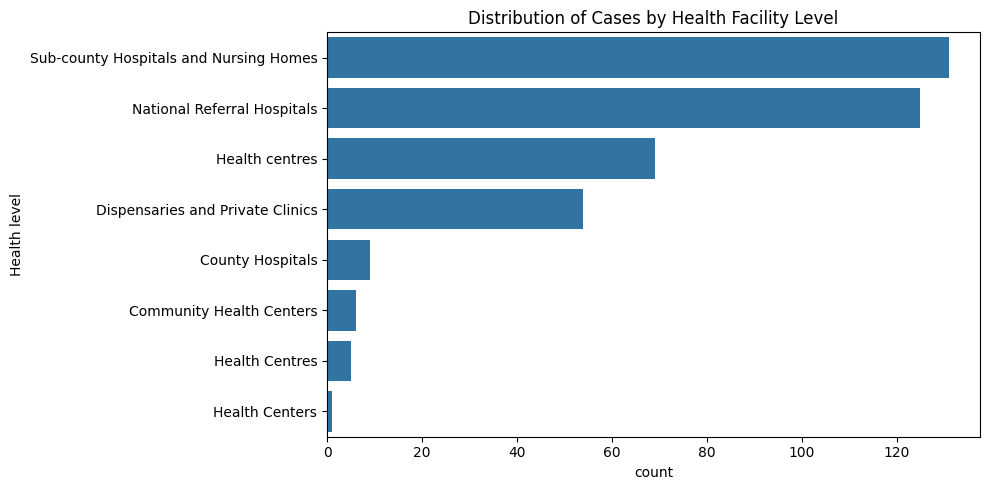

In [55]:
# Health Facility Level Distribution
df['Health level'].value_counts()
plt.figure(figsize=(10,5))
sns.countplot(y='Health level', data=df, order=df['Health level'].value_counts().index)
plt.title('Distribution of Cases by Health Facility Level')
plt.tight_layout()
plt.show()

In [56]:
# Clinical Specialty Distribution (Clinical Panel)
df['Clinical Panel_clean'].value_counts()


Clinical Panel_clean
INTERNAL MEDICINE               133
SURGERY                          91
PAEDIATRICS                      78
OBSTETRICS AND GYNAECOLOGY       68
CRITICAL CARE                    18
INTERNAL MEDICINE/PSYCHIATRY      3
SURGERY PAEDIATRICS               2
SURGERY (ENT)                     1
INTERNAL MEDICINE/CARDIOLOGY      1
PAEDIATRIC NEUROLOGY              1
PSYCHIATRY                        1
SURGERY/OPTHALMOLOGY              1
INTERNAL MEDICINE/SURGERY         1
CRITICAL CARE/SURGERY             1
Name: count, dtype: int64

In [57]:
# First, let's check what our cleaned data looks like now
print("=== DEBUGGING - DATA INSPECTION ===\n")

# Check the first few rows of cleaned Clinician text
print("1. First 3 Clinician_clean entries:")
for i in range(3):
    print(f"   Row {i}: '{df['Clinician_clean'].iloc[i]}'")
    print()

# Check the first few rows of cleaned DDX SNOMED text
print("2. First 3 DDX SNOMED_clean entries:")
for i in range(3):
    print(f"   Row {i}: '{df['DDX SNOMED_clean'].iloc[i]}'")
    print()

# Let's test our regex patterns on sample data
print("3. Testing regex patterns on sample data:")
sample_text = df['Clinician_clean'].iloc[0]
print(f"   Sample text: '{sample_text}'")

# Test individual patterns
test_patterns = ["summary", "year old", "plan", "manage", "\\d+ year", "give"]
for pattern in test_patterns:
    matches = re.findall(pattern, sample_text, re.IGNORECASE)
    print(f"   Pattern '{pattern}': {len(matches)} matches - {matches}")

print("\n4. Testing SNOMED code extraction:")
sample_ddx = df['DDX SNOMED_clean'].iloc[0]
print(f"   Sample DDX: '{sample_ddx}'")
codes_found = re.findall(r'\b(\d{5,})\b', sample_ddx)
print(f"   SNOMED codes found: {codes_found}")

=== DEBUGGING - DATA INSPECTION ===

1. First 3 Clinician_clean entries:
   Row 0: 'Summary: A 4 year old with 5% superficial burns. No other injuries Immediate Management: * Paracetamol analgesics to to ensure child has minimal or no pain * Cleaning and frosting of wound with silver sulpha-fizika * Topical prophylactic can be considered in this case * Good nutrition - high protein diet'

   Row 1: 'Summary 6-year-old present with vomiting and abdominal pains. Known diabetic on insulin but doesn’t take it as scheduled due to lack of funds. He is confused, Kussmaul breathing, fruity-scented breath, dry tongue & blurry vision. Vitals: Temp (N), pulse ↑ (120), BP ↓ (48), rapid laboured SpO₂ 90%. Diagnosis: Diabetic Ketoacidosis (DKA) in known DM type 1 patient due to insulin insufficiency and uncompliance. Differentials Sepsis in a knon diabetic patient Investigations: 1. Laboratory investigations: Urinalysis Blood gas analysis RBS HbA1c UECs CBC Management: 1. Insert IV large bore cannul

In [58]:
# Analysis of the CLINICIAN's Response Pattern 
all_clinician_text = " ".join(df['Clinician_clean'].dropna().tolist())
print(f"Length of all clinician text: {len(all_clinician_text)} characters")
print(f"First 200 chars: '{all_clinician_text[:200]}...'")

categories = {
    "Introduction": ["summary", "present", "complains", "complaining", "year old"],
    "Assessment": ["assessment", "diagnosis", "impression", "likely", "consistent", "cause"],
    "Plan": ["plan", "manage", "administer", "refer", "investigate", "monitor", "give", "start"]
}

pattern_counts = {}
for category, patterns in categories.items():
    total_count = 0
    print(f"\n--- {category} ---")
    for pattern in patterns:
        count = len(re.findall(pattern, all_clinician_text, re.IGNORECASE))
        total_count += count
        print(f"  {pattern}: {count}")
    pattern_counts[category] = total_count

print(f"\nFinal pattern counts: {pattern_counts}")

Length of all clinician text: 286834 characters
First 200 chars: 'Summary: A 4 year old with 5% superficial burns. No other injuries Immediate Management: * Paracetamol analgesics to to ensure child has minimal or no pain * Cleaning and frosting of wound with silver...'

--- Introduction ---
  summary: 326
  present: 173
  complains: 11
  complaining: 6
  year old: 159

--- Assessment ---
  assessment: 47
  diagnosis: 231
  impression: 14
  likely: 26
  consistent: 1
  cause: 123

--- Plan ---
  plan: 30
  manage: 388
  administer: 177
  refer: 152
  investigate: 10
  monitor: 153
  give: 213
  start: 91

Final pattern counts: {'Introduction': 675, 'Assessment': 442, 'Plan': 1214}


In [63]:
#  Keyword and Topic Analysis
stop_words = set(stopwords.words('english'))
clinical_stopwords = {'patient', 'patients', 'present', 'presents', 'history', 'year', 'old', 'female', 'male', 'summary'}
all_stopwords = stop_words.union(clinical_stopwords)
all_clinician_text = " ".join(df['Clinician_clean'].dropna().tolist())
all_clinician_text_lower = all_clinician_text.lower()

words = re.findall(r'[a-z0-9]+(?:-[a-z0-9]+)*', all_clinician_text_lower)
print(f"Total words extracted: {len(words)}")

word_freq_unfiltered = Counter(words).most_common(15)
print("\nTop 15 words BEFORE filtering (stopwords included):")
for word, freq in word_freq_unfiltered:
    print(f"  {word}: {freq}")

filtered_words = [word for word in words if word not in all_stopwords and len(word) > 2]

word_freq = Counter(filtered_words).most_common(25)

print(f"\nTop 25 words AFTER filtering (stopwords removed):")
for word, freq in word_freq:
    print(f"  {word}: {freq}")

keyword_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])
print(f"\nFinal keyword analysis DataFrame:")
print(keyword_df.head(10).to_string())

keyword_df

Total words extracted: 42870

Top 15 words BEFORE filtering (stopwords included):
  the: 1360
  and: 1255
  to: 1083
  of: 937
  for: 925
  a: 908
  with: 648
  is: 535
  patient: 460
  blood: 395
  on: 393
  summary: 325
  in: 319
  management: 315
  be: 259

Top 25 words AFTER filtering (stopwords removed):
  blood: 395
  management: 315
  diagnosis: 230
  pain: 226
  investigations: 196
  give: 178
  administer: 164
  check: 154
  vitals: 150
  antibiotics: 124
  monitor: 121
  full: 120
  normal: 119
  function: 117
  examination: 115
  fluids: 113
  infection: 113
  abdominal: 111
  chest: 110
  assess: 105
  count: 104
  signs: 102
  test: 101
  oxygen: 97
  tests: 95

Final keyword analysis DataFrame:
             Word  Frequency
0           blood        395
1      management        315
2       diagnosis        230
3            pain        226
4  investigations        196
5            give        178
6      administer        164
7           check        154
8          vitals    

,Word,Frequency
0,blood,395
1,management,315
2,diagnosis,230
3,pain,226
4,investigations,196
5,give,178
6,administer,164
7,check,154
8,vitals,150
9,antibiotics,124


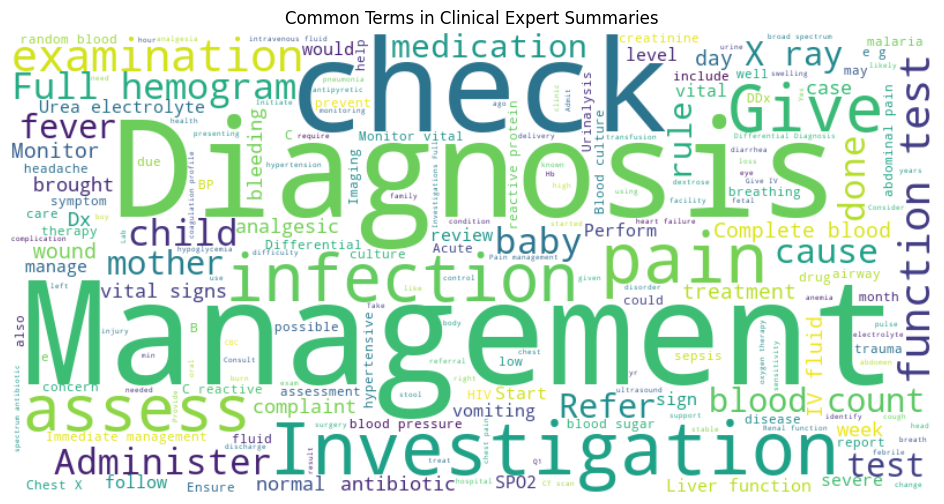

In [65]:
# Wordcloud Visualization

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=all_stopwords).generate(all_clinician_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Terms in Clinical Expert Summaries')
plt.show()


In [66]:
# 🔍 Analysis of DDX SNOMED Codes: Structured Data

# Inspect a few rows to compare original vs cleaned
for i in range(3):
    print(f"Row {i}:")
    display(pd.DataFrame({
        "Original": [df['DDX SNOMED'].iloc[i]],
        "Cleaned": [df['DDX SNOMED_clean'].iloc[i]]
    }))
    print()

# Test different regex patterns for SNOMED codes
test_patterns = [
    r'\b(\d{5,})\b',      # 5+ digits
    r'\b(\d{6,})\b',      # 6+ digits
    r'\b(\d{4,})\b',      # 4+ digits
    r'\b(\d{3,})\b',      # 3+ digits
]

sample_ddx = df['DDX SNOMED_clean'].iloc[0]

print("Testing regex patterns on sample DDX entry:")
print(f"Sample: '{sample_ddx}'")

# Collect matches for each regex
results = {pattern: re.findall(pattern, sample_ddx) for pattern in test_patterns}

# Display neatly as a table
pd.DataFrame([
    {"Pattern": pat, "Matches": matches} 
    for pat, matches in results.items()
])


Row 0:


,Original,Cleaned
0,288514009 | Burn involving 5 percent of body s...,288514009 | Burn involving 5 percent of body s...



Row 1:


,Original,Cleaned
0,420270002 | Ketoacidosis due to type 1 diabete...,420270002 | Ketoacidosis due to type 1 diabete...



Row 2:


,Original,Cleaned
0,13200003 | Peptic ulcer (disorder)\n25458004 |...,13200003 | Peptic ulcer (disorder) 25458004 | ...



Testing regex patterns on sample DDX entry:
Sample: '288514009 | Burn involving 5 percent of body surface (disorder)'


,Pattern,Matches
0,"\b(\d{5,})\b",[288514009]
1,"\b(\d{6,})\b",[288514009]
2,"\b(\d{4,})\b",[288514009]
3,"\b(\d{3,})\b",[288514009]


In [68]:
# Step 3: Create structured input-output pairs for training

train_df = pd.DataFrame()
train_df['input_text'] = "CLINICAL CASE: " + df['Clinician_clean'] + " NURSE CONTEXT: " + df['Prompt_clean']
train_df['target_text'] = df['Clinician_clean']

display(pd.DataFrame({
    "Sample Input": [train_df['input_text'].iloc[0][:500] + "..."],
    "Target Output": [train_df['target_text'].iloc[0][:500] + "..."]
}))

output_path_structured = "../data/train_structured_for_fine_tuning.csv"
train_df.to_csv(output_path_structured, index=False)

print(f"Structured training data saved to: {output_path_structured}")
train_df.shape


,Sample Input,Target Output
0,CLINICAL CASE: Summary: A 4 year old with 5% s...,Summary: A 4 year old with 5% superficial burn...


Structured training data saved to: ../data/train_structured_for_fine_tuning.csv


(400, 2)

In [71]:
# Save the complete cleaned dataset
output_path_complete = "../data/clinical_cases_complete_clean.csv"
df.to_csv(output_path_complete, index=False, encoding='utf-8')

print(f"Complete cleaned dataset saved to: {output_path_complete}")
df.shape


Complete cleaned dataset saved to: ../data/clinical_cases_complete_clean.csv


(400, 21)

In [73]:
# Structured dataset for model training

train_df = pd.DataFrame()
train_df['input_text'] = "CLINICAL CASE: " + df['Clinician_clean'] + " NURSE CONTEXT: " + df['Prompt_clean']
train_df['target_text'] = df['Clinician_clean']
train_df['master_index'] = df['Master_Index']
train_df['clinical_panel'] = df['Clinical Panel']

output_path_training = "../data/clinical_cases_training_ready.csv"
train_df.to_csv(output_path_training, index=False, encoding='utf-8')

print(f"Training-ready dataset saved to: {output_path_training}")
train_df.shape


Training-ready dataset saved to: ../data/clinical_cases_training_ready.csv


(400, 4)